## Objective of the case study
* Perform descriptive analytics to create a customer profile for each AeroFit
treadmill product by developing appropriate tables and charts.
* For each AeroFit treadmill product, construct two-way contingency tables and compute all conditional and marginal probabilities along with their insights/impact on the business.

In [53]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import binom,poisson,norm,expon,geom,uniform

In [3]:
# Importing Dataset

df = pd.read_csv('aerofit_data.csv')
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
# Checking the dataset and understanding the datatypes, size and null values

In [9]:
print('The sie of the dataframe is:',df.shape)

The sie of the dataframe is: (180, 9)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [10]:
df['Product'].value_counts()

,count
Product,
KP281,80
KP481,60
KP781,40


# Comments:

### * Overall we have 180 rows and 9 columns with no Null values
### * Since the objective is to create a customer profile based on the data given for each treadmill so the approach would be to take a treadmill, create a customer profile and replicate the same for other treadmills. Will start with the highest selling treadmill

## KP281 Product

In [186]:
first_product = df[df['Product'] == 'KP281']
first_product.shape # All the data belong to KP281 are filtered

(80, 9)

In [187]:
first_product.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [23]:
first_product.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,80.000000,80.000000,80.000000,80.00000,80.00000,80.000000
mean,28.550000,15.037500,3.087500,2.96250,46418.02500,82.787500
std,7.221452,1.216383,0.782624,0.66454,9075.78319,28.874102
min,18.000000,12.000000,2.000000,1.00000,29562.00000,38.000000
25%,23.000000,14.000000,3.000000,3.00000,38658.00000,66.000000
50%,26.000000,16.000000,3.000000,3.00000,46617.00000,85.000000
75%,33.000000,16.000000,4.000000,3.00000,53439.00000,94.000000
max,50.000000,18.000000,5.000000,5.00000,68220.00000,188.000000


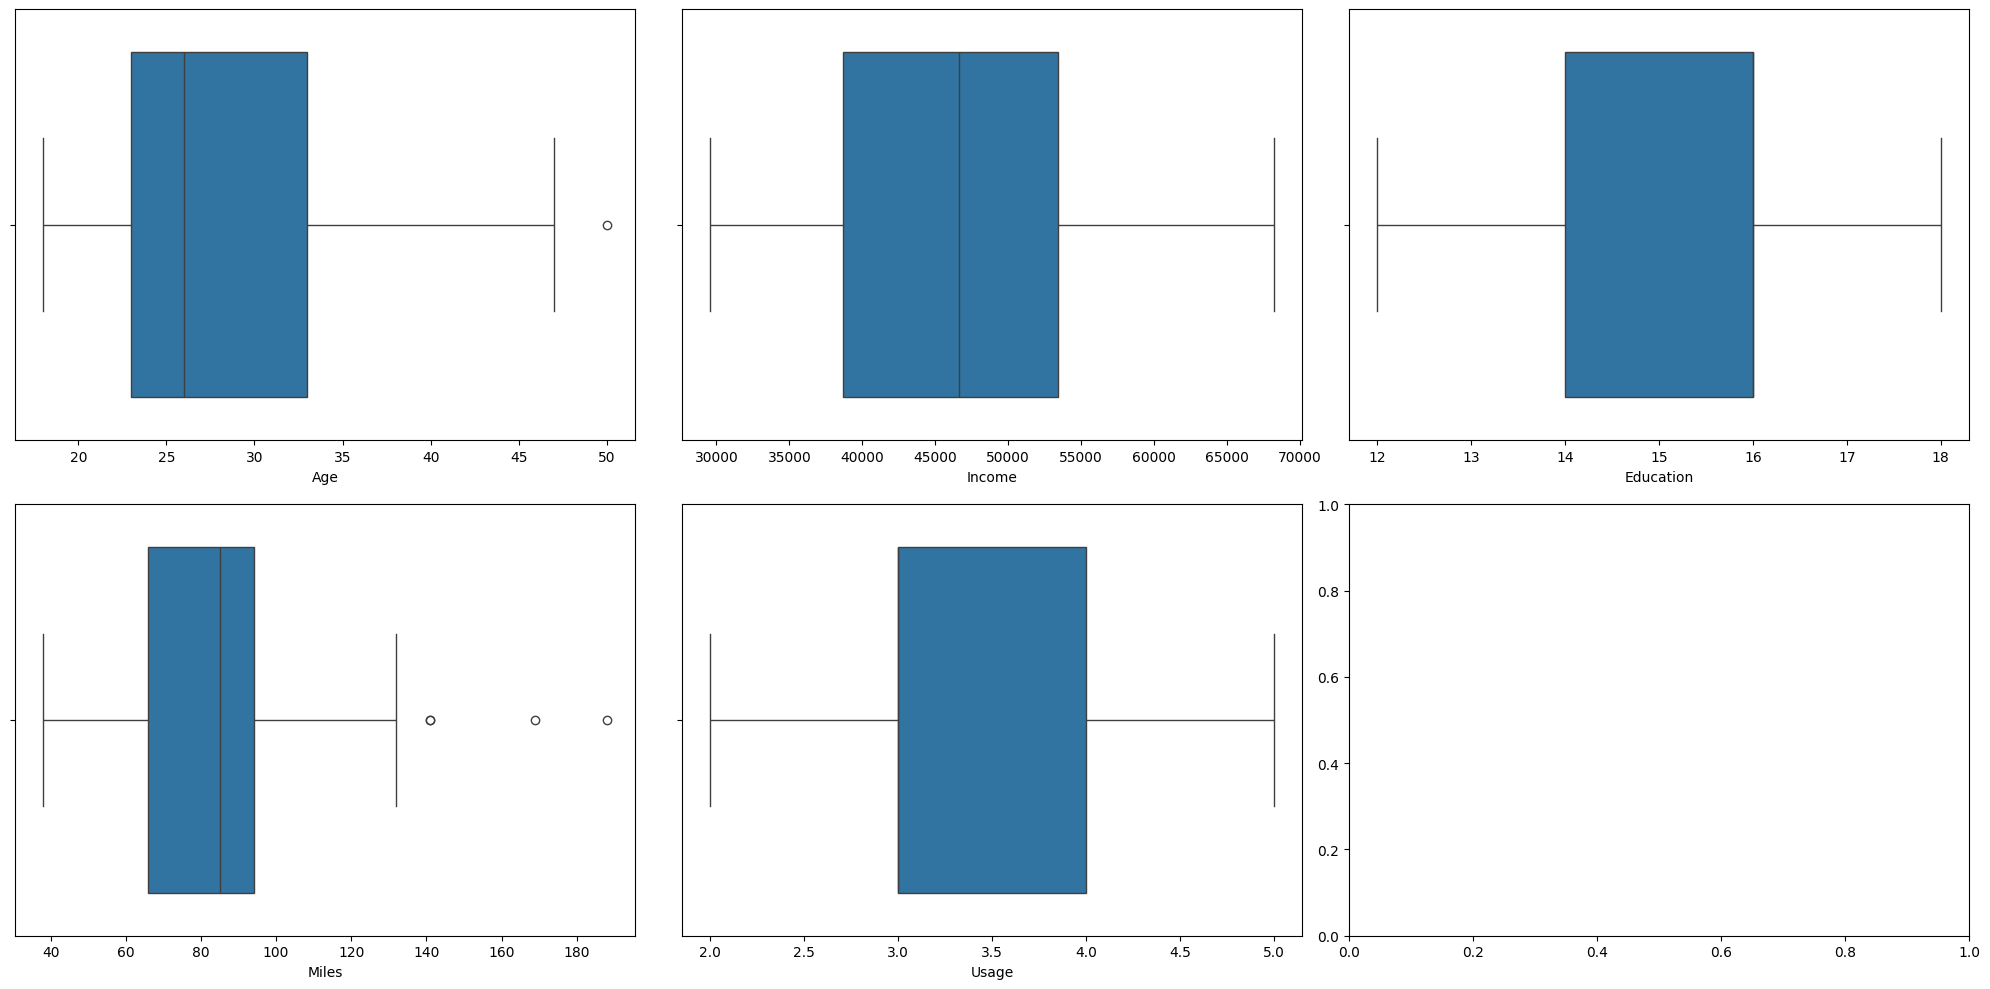

In [69]:
# First check for outliers for all columns

fig, ax = plt.subplots(2, 3, figsize=(20, 10))

sns.boxplot(x=first_product['Age'], ax=ax[0, 0])
sns.boxplot(x=first_product['Income'], ax=ax[0, 1])
sns.boxplot(x=first_product['Education'], ax=ax[0, 2])
sns.boxplot(x=first_product['Miles'], ax=ax[1, 0])
sns.boxplot(x=first_product['Usage'], ax=ax[1, 1])


plt.tight_layout()
plt.show()

In [67]:
first_product.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,80.000000,80.000000,80.000000,80.00000,80.00000,80.000000
mean,28.550000,15.037500,3.087500,2.96250,46418.02500,82.787500
std,7.221452,1.216383,0.782624,0.66454,9075.78319,28.874102
min,18.000000,12.000000,2.000000,1.00000,29562.00000,38.000000
25%,23.000000,14.000000,3.000000,3.00000,38658.00000,66.000000
50%,26.000000,16.000000,3.000000,3.00000,46617.00000,85.000000
75%,33.000000,16.000000,4.000000,3.00000,53439.00000,94.000000
max,50.000000,18.000000,5.000000,5.00000,68220.00000,188.000000


# Comments

### * It is clear from the abvoe graph that there are no outliers in the given data set, so we will move to the descriptive statistics
### * We will start with the univariate analysis and once we determine the influencing factors we will switch to bi-variate analysis
### * Under univariate analysis, we can address the following question:

*   Age: What is the typical age range of customers? Are there any age groups that buy more than others?
*   Gender: What is the gender distribution of customers?
*   Education: What are the common education levels of customers?
*   MaritalStatus: What is the marital status distribution of customers? Are they mostly single or partnered?
*   Usage: How often do customers plan to use the treadmill per week? What is the most common planned usage?
*   Fitness: How do customers rate their own fitness level? What is the average self-rated fitness level?
*   Income: What is the income distribution of customers? What is the average income?

In [ ]:
first_product.head(5)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group
0,KP281,18,Male,14,Single,3,4,29562,112,NaN
1,KP281,19,Male,15,Single,2,3,31836,75,NaN
2,KP281,19,Female,14,Partnered,4,3,30699,66,NaN
3,KP281,19,Male,12,Single,3,3,32973,85,NaN
4,KP281,20,Male,13,Partnered,4,2,35247,47,NaN


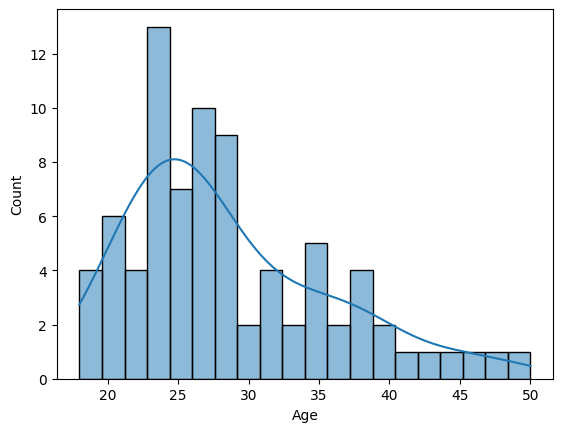

In [72]:
# Age: What is the typical age range of customers? Are there any age groups that buy more than others?

sns.histplot(first_product['Age'],bins=20,kde=True)
plt.show()

# From the graph its clear that the product is famous amongst the age group between 25-30, however for better clarity lets
# divide the age into bins and understand their distribution

In [79]:
# Creating bins for age group

bins = [18, 25, 30, 35, 40, 45,50]
labels = ['18-25', '25-30', '30-35', '35-40','40-45','45-50']

first_product['Age_Group'] = pd.cut(first_product['Age'], bins=bins, labels=labels, right=False)

/tmp/ipython-input-885679384.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_product['Age_Group'] = pd.cut(first_product['Age'], bins=bins, labels=labels, right=False)


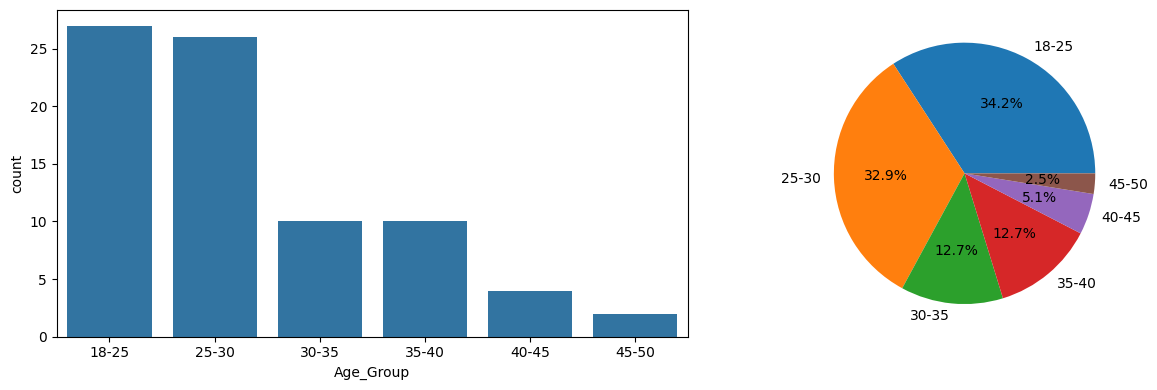

In [97]:
# Lets understand the distribution of the data as per age group for better clarity

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x='Age_Group',data=first_product, ax=ax[0])
ax[1].pie(first_product['Age_Group'].value_counts(),labels=first_product['Age_Group'].value_counts().index,autopct='%1.1f%%')

plt.tight_layout()
plt.show()

In [ ]:
# It is clear from above graph that customers from age groups between 18-30 consititues major portion (65%)

<Axes: xlabel='count', ylabel='Gender'>

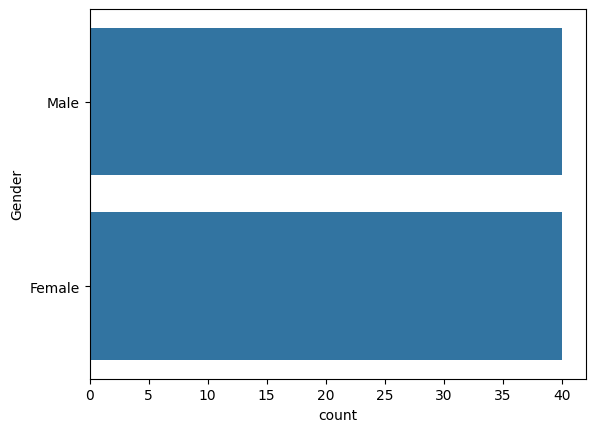

In [98]:
# Gender: What is the gender distribution of customers?

sns.countplot(first_product['Gender'])

In [ ]:
# There is an equal proportion between both genders, hence there is no clear winner

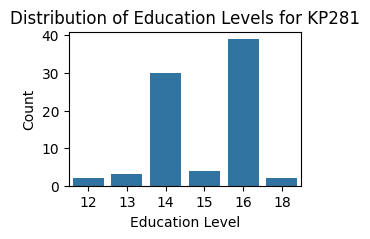

In [107]:
# Education: What are the common education levels of customers?

education_counts = first_product['Education'].value_counts().sort_index()  # Taking discrete values of the Education and then plotting it

plt.figure(figsize=(3, 2))
sns.barplot(x=education_counts.index, y=education_counts.values)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Distribution of Education Levels for KP281')
plt.show()

In [113]:
# the above graphs shows that education grup 16 and 14 are most preferred ones

<Axes: xlabel='count', ylabel='MaritalStatus'>

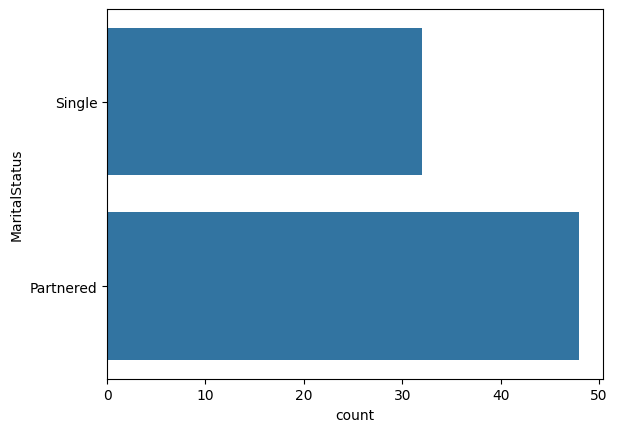

In [114]:
# MaritalStatus: What is the marital status distribution of customers? Are they mostly single or partnered?

sns.countplot(first_product['MaritalStatus'])

In [ ]:
# Partenred i.e. Maried couples are frequent buyer of this product

<Axes: ylabel='count'>

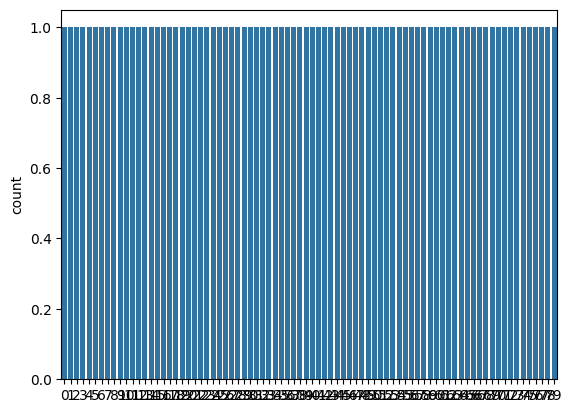

In [116]:
# Usage: How often do customers plan to use the treadmill per week? What is the most common planned usage?

sns.countplot(first_product['Usage'])

# Countplot might be interpreting the numerical data as continous instead of discrete.
# This is causing it to group all values together. Lets calculate the data and use it
# to plot the graph

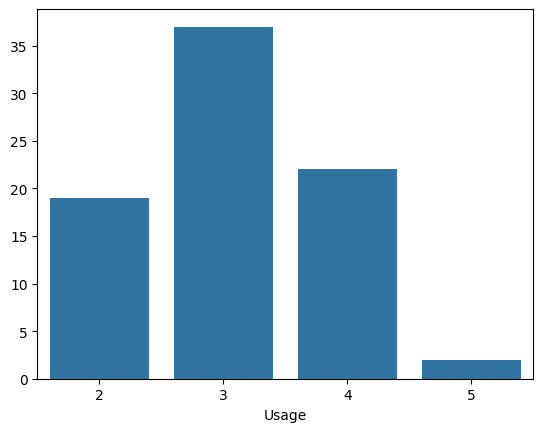

In [121]:
usage_counts = first_product['Usage'].value_counts().sort_index()
usage_counts

sns.barplot(x = usage_counts.index,y=usage_counts.values)
plt.show()

In [122]:
# It is famous amonst the people who wants to use it 3 times in a week

<Axes: ylabel='Fitness'>

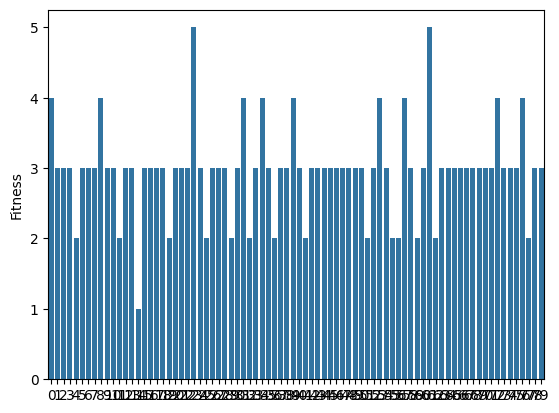

In [124]:
# Fitness: How do customers rate their own fitness level? What is the average self-rated fitness level?

sns.countplot(first_product['Fitness'])

# Repeatig the similar activity to convert continous to discrete

<Axes: xlabel='Fitness'>

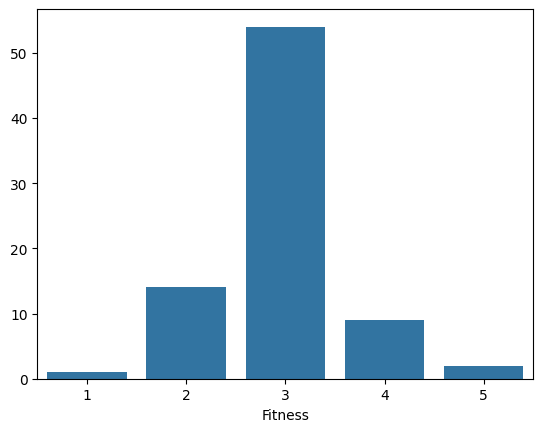

In [127]:
fitness_counts = first_product['Fitness'].value_counts().sort_index()


sns.barplot(x = fitness_counts.index,y=fitness_counts.values)

In [128]:
# Customer who are rating themselves 3 are taking this product

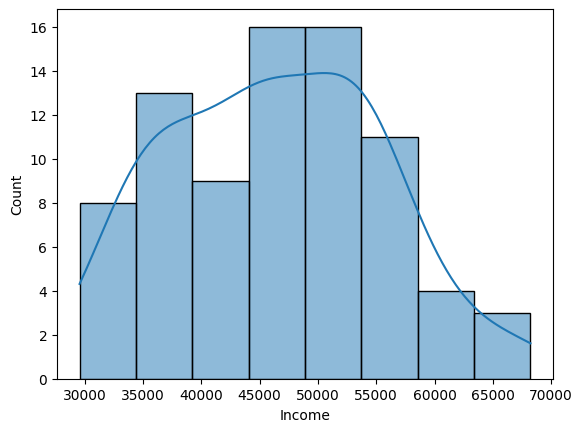

In [130]:
# Income: What is the income distribution of customers? What is the average income?

sns.histplot(first_product['Income'],kde=True)
plt.show()

In [ ]:
# Customers whose income is between $ 45000 - $55000 prefers the product

# Summarizing the findings till now (Customer Profile for KP281):

Based on the univariate analysis for the KP281 product, the typical customer is between 18 and 30 years old, making up about 65% of buyers, with a nearly equal distribution between genders. They commonly have education levels of 14 or 16 years and are more likely to be partnered. These customers primarily plan to use the treadmill 3 times per week and rate their fitness level as 3. Their income typically falls between $45,000 and $55,000.

## KP481 Product

In [132]:
second_product = df[df['Product'] == 'KP481']
second_product.shape # All the data belong to KP281 are filtered

(60, 9)

In [133]:
second_product.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
80,KP481,19,Male,14,Single,3,3,31836,64
81,KP481,20,Male,14,Single,2,3,32973,53
82,KP481,20,Female,14,Partnered,3,3,34110,106
83,KP481,20,Male,14,Single,3,3,38658,95
84,KP481,21,Female,14,Partnered,5,4,34110,212


In [134]:
second_product.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,60.000000,60.000000,60.000000,60.00000,60.000000,60.000000
mean,28.900000,15.116667,3.066667,2.90000,48973.650000,87.933333
std,6.645248,1.222552,0.799717,0.62977,8653.989388,33.263135
min,19.000000,12.000000,2.000000,1.00000,31836.000000,21.000000
25%,24.000000,14.000000,3.000000,3.00000,44911.500000,64.000000
50%,26.000000,16.000000,3.000000,3.00000,49459.500000,85.000000
75%,33.250000,16.000000,3.250000,3.00000,53439.000000,106.000000
max,48.000000,18.000000,5.000000,4.00000,67083.000000,212.000000


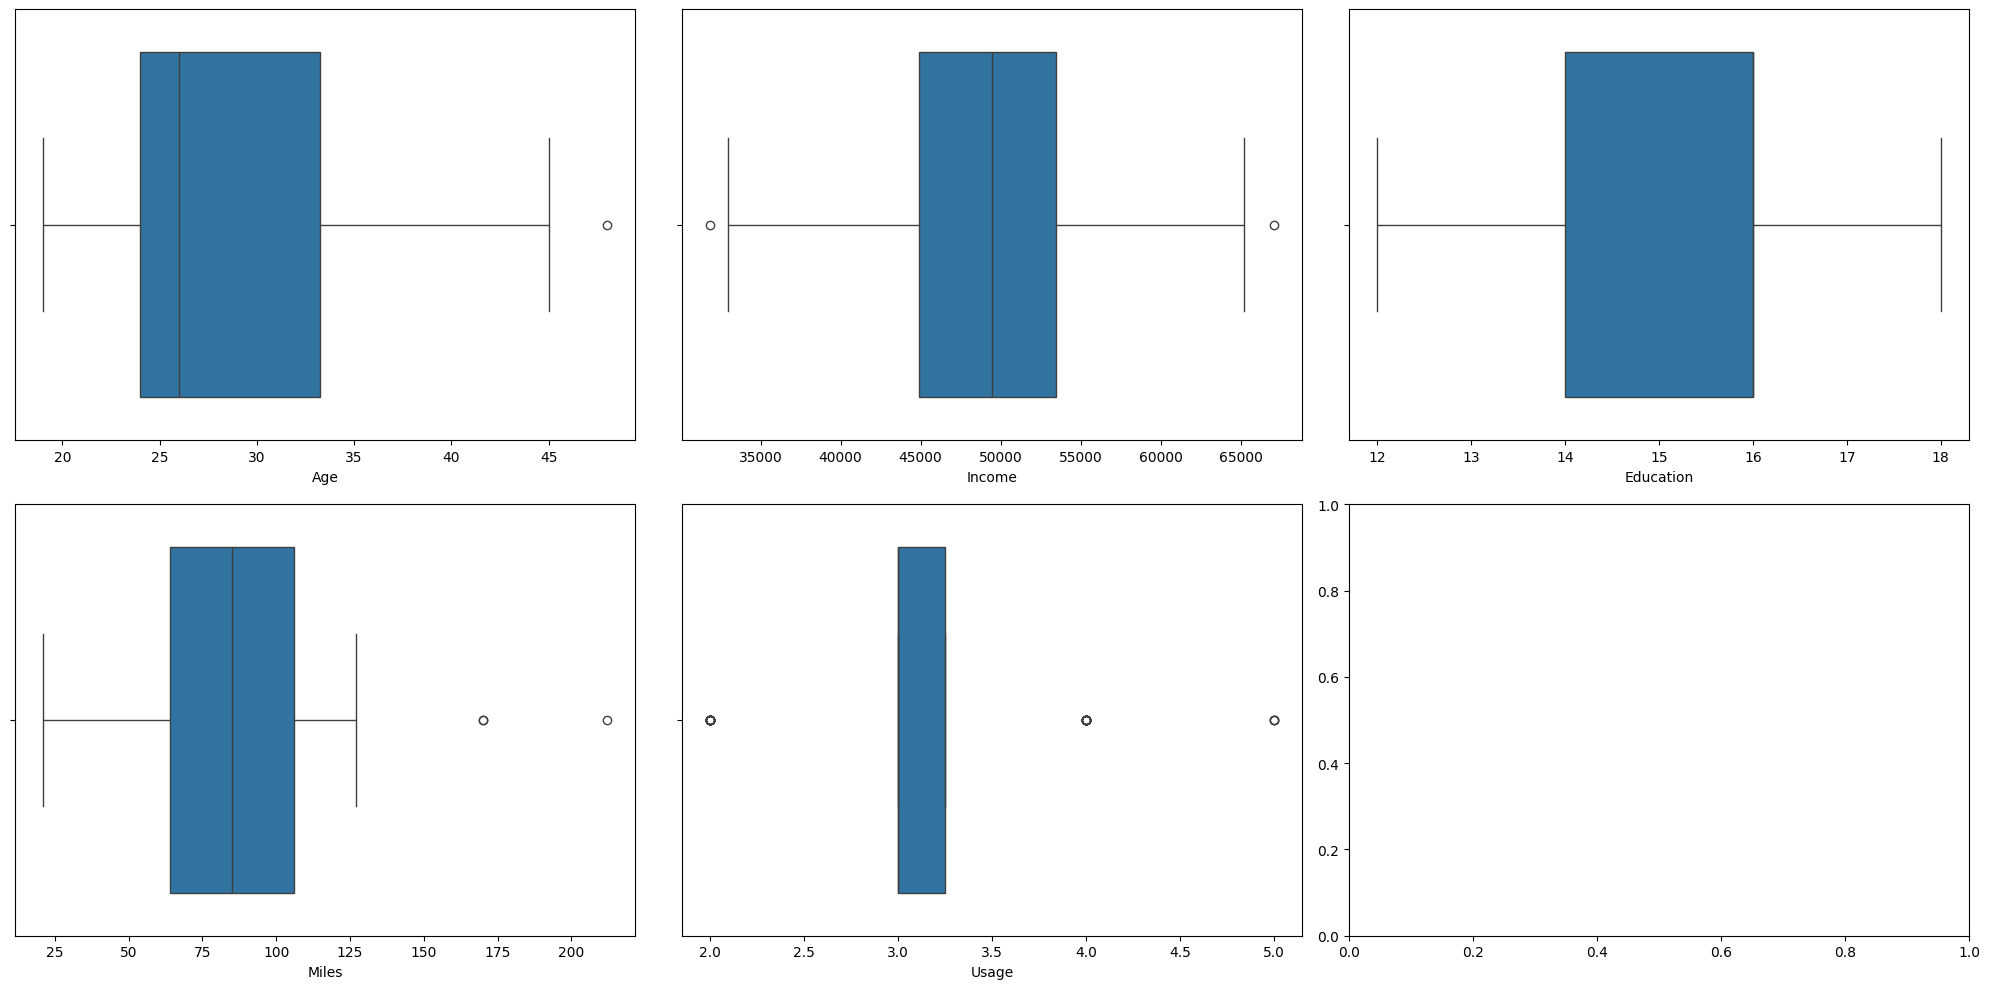

In [135]:
# First check for outliers for all columns

fig, ax = plt.subplots(2, 3, figsize=(20, 10))

sns.boxplot(x=second_product['Age'], ax=ax[0, 0])
sns.boxplot(x=second_product['Income'], ax=ax[0, 1])
sns.boxplot(x=second_product['Education'], ax=ax[0, 2])
sns.boxplot(x=second_product['Miles'], ax=ax[1, 0])
sns.boxplot(x=second_product['Usage'], ax=ax[1, 1])


plt.tight_layout()
plt.show()

In [ ]:
# There are some outliers so let's treat them

In [141]:
# Outliers treatment for Age

q1 = second_product['Age'].quantile(0.25)
q3 = second_product['Age'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

second_product_mod1 = second_product[(second_product['Age'] >= lower_bound) & (second_product['Age'] <= upper_bound)]

In [142]:
# Outliers treatment for Income

q1 = second_product['Income'].quantile(0.25)
q3 = second_product['Income'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

second_product_mod2 = second_product_mod1[(second_product_mod1['Income'] >= lower_bound) & (second_product_mod1['Income'] <= upper_bound)]

In [143]:
# Outliers treatment for Miles

q1 = second_product_mod2['Miles'].quantile(0.25)
q3 = second_product_mod2['Miles'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

second_product_final = second_product_mod2[(second_product_mod2['Miles'] >= lower_bound) & (second_product_mod2['Miles'] <= upper_bound)]


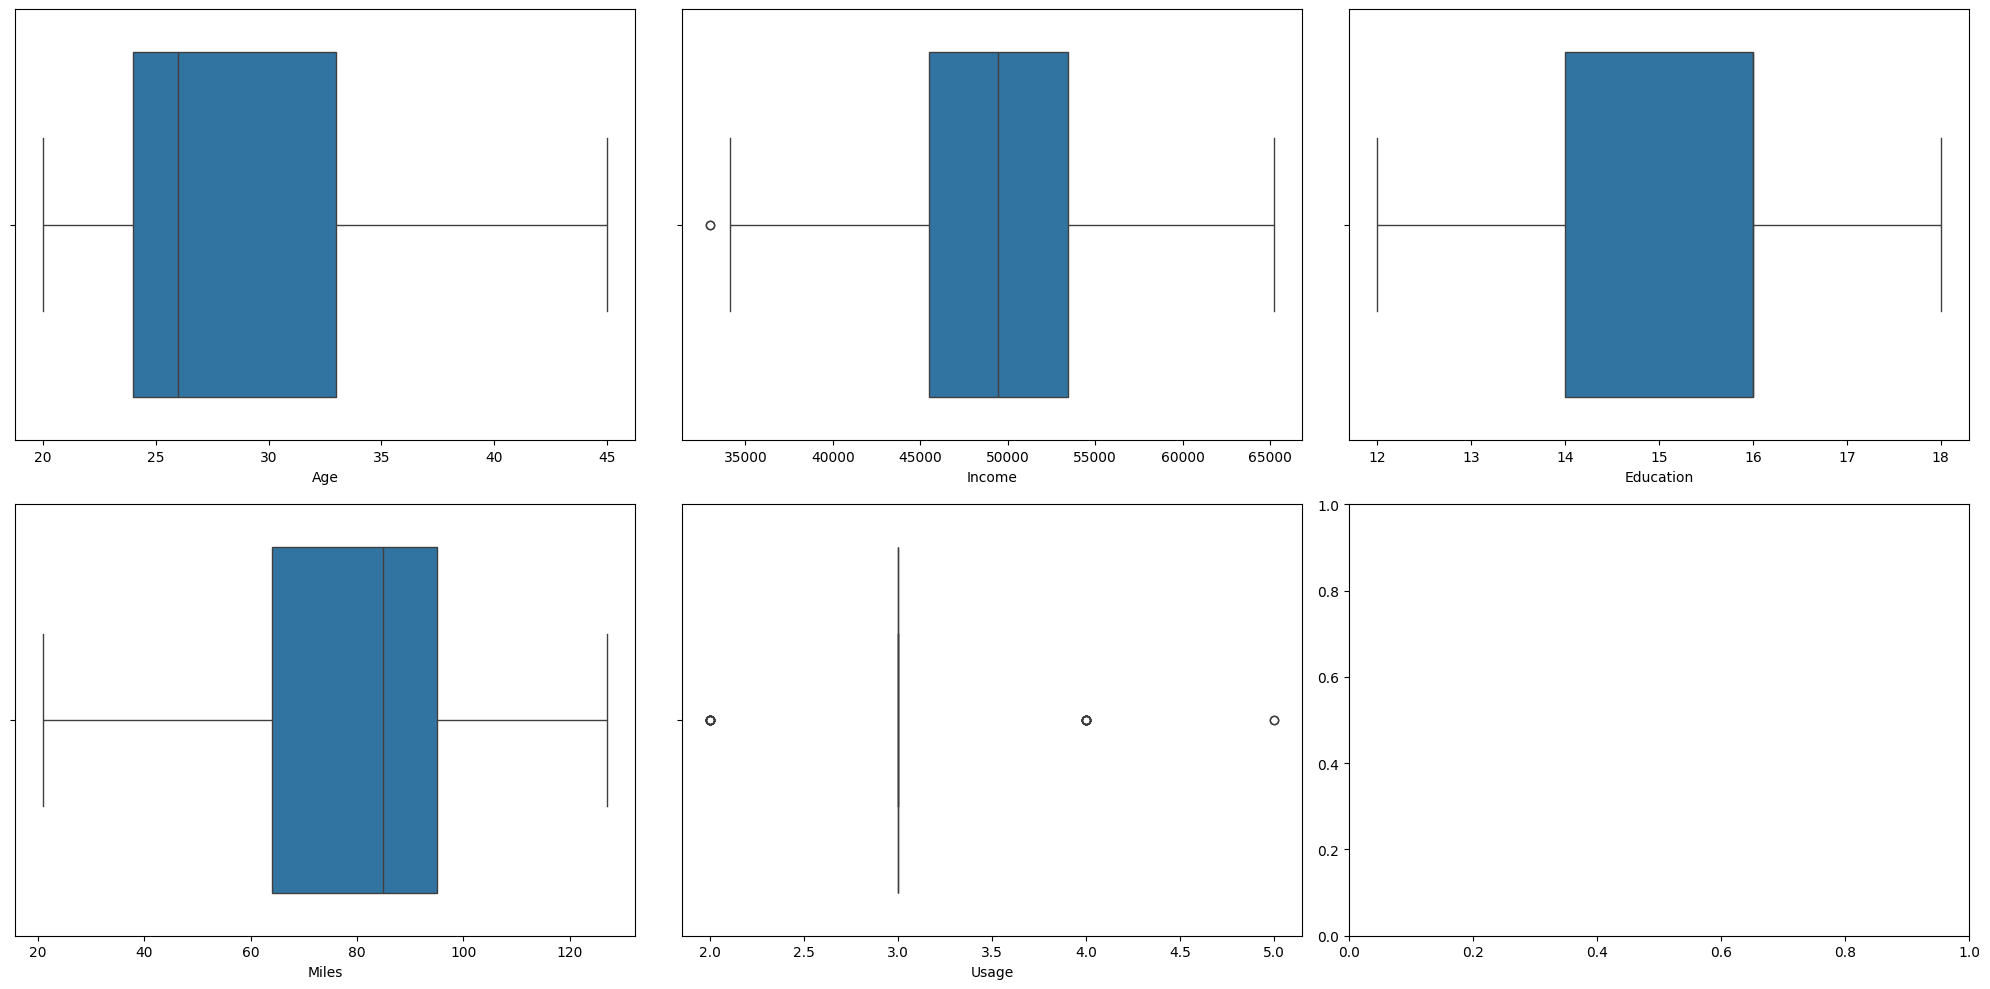

In [144]:
# Redrawing the box plot

fig, ax = plt.subplots(2, 3, figsize=(20, 10))

sns.boxplot(x=second_product_final['Age'], ax=ax[0, 0])
sns.boxplot(x=second_product_final['Income'], ax=ax[0, 1])
sns.boxplot(x=second_product_final['Education'], ax=ax[0, 2])
sns.boxplot(x=second_product_final['Miles'], ax=ax[1, 0])
sns.boxplot(x=second_product_final['Usage'], ax=ax[1, 1])


plt.tight_layout()
plt.show()

In [145]:
second_product_final.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,28.777778,15.203704,3.018519,2.851852,49046.000000,83.537037
std,6.175627,1.219026,0.764563,0.626684,8082.541899,25.409635
min,20.000000,12.000000,2.000000,1.000000,32973.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,45480.000000,64.000000
50%,26.000000,16.000000,3.000000,3.000000,49459.500000,85.000000
75%,33.000000,16.000000,3.000000,3.000000,53439.000000,95.000000
max,45.000000,18.000000,5.000000,4.000000,65220.000000,127.000000


# Comments

### Post Outliers are treated, lets dig into uni-variate analysis
*   Age: What is the typical age range of customers? Are there any age groups that buy more than others?
*   Gender: What is the gender distribution of customers?
*   Education: What are the common education levels of customers?
*   MaritalStatus: What is the marital status distribution of customers? Are they mostly single or partnered?
*   Usage: How often do customers plan to use the treadmill per week? What is the most common planned usage?
*   Fitness: How do customers rate their own fitness level? What is the average self-rated fitness level?
*   Income: What is the income distribution of customers? What is the average income?

In [146]:
second_product_final.head(5)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
81,KP481,20,Male,14,Single,2,3,32973,53
82,KP481,20,Female,14,Partnered,3,3,34110,106
83,KP481,20,Male,14,Single,3,3,38658,95
85,KP481,21,Male,16,Partnered,2,2,34110,42
86,KP481,21,Male,12,Partnered,2,2,32973,53


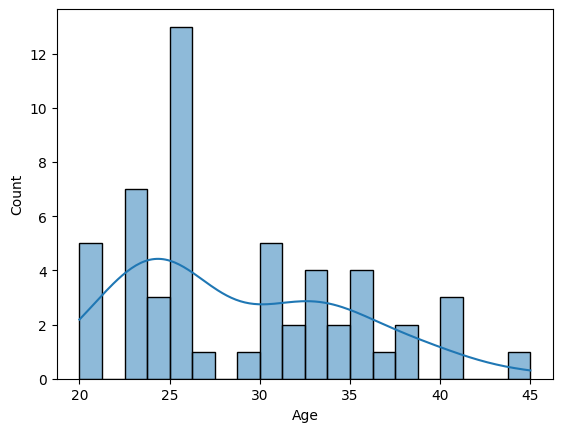

In [147]:
# Age: What is the typical age range of customers? Are there any age groups that buy more than others?

sns.histplot(second_product_final['Age'],bins=20,kde=True)
plt.show()

# From the graph its clear that the product is famous amongst the age group between 22-26, however for better clarity lets
# divide the age into bins and understand their distribution

In [148]:
# Creating bins for age group

bins = [18, 25, 30, 35, 40, 45,50]
labels = ['18-25', '25-30', '30-35', '35-40','40-45','45-50']

second_product_final['Age_Group'] = pd.cut(second_product_final['Age'], bins=bins, labels=labels, right=False)

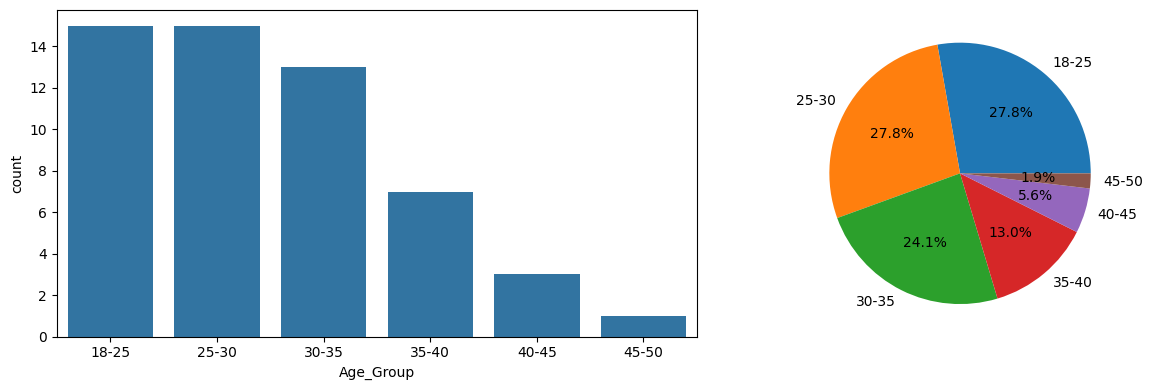

In [149]:
# Lets understand the distribution of the data as per age group for better clarity

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x='Age_Group',data=second_product_final, ax=ax[0])
ax[1].pie(second_product_final['Age_Group'].value_counts(),labels=second_product_final['Age_Group'].value_counts().index,autopct='%1.1f%%')

plt.tight_layout()
plt.show()

In [ ]:
# It is clear from above graph that customers from age groups between 18-35 consititues major portion (78%)

<Axes: xlabel='count', ylabel='Gender'>

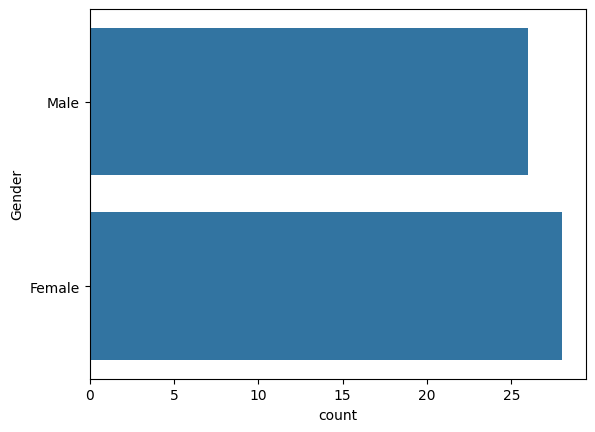

In [150]:
# Gender: What is the gender distribution of customers?

sns.countplot(second_product_final['Gender'])

In [ ]:
# Female customers prefer this product more than their counterpart

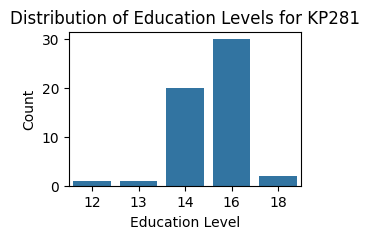

In [151]:
# Education: What are the common education levels of customers?

education_counts = second_product_final['Education'].value_counts().sort_index()  # Taking discrete values of the Education and then plotting it

plt.figure(figsize=(3, 2))
sns.barplot(x=education_counts.index, y=education_counts.values)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Distribution of Education Levels for KP281')
plt.show()

In [ ]:
# the above graphs shows that education grup 16 and 14 are most preferred ones

<Axes: xlabel='count', ylabel='MaritalStatus'>

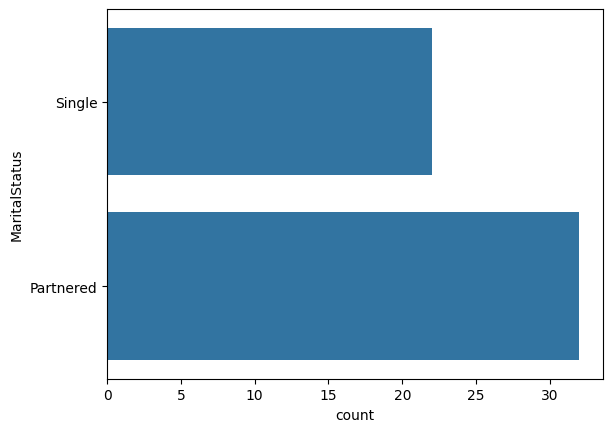

In [152]:
# MaritalStatus: What is the marital status distribution of customers? Are they mostly single or partnered?

sns.countplot(second_product_final['MaritalStatus'])

In [ ]:
# Partenred i.e. Maried couples are frequent buyer of this product

<Axes: ylabel='count'>

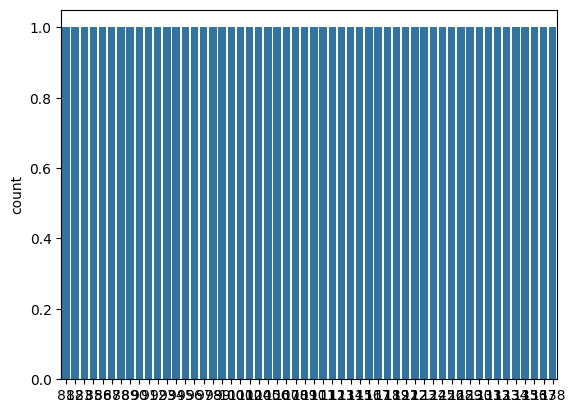

In [153]:
# Usage: How often do customers plan to use the treadmill per week? What is the most common planned usage?

sns.countplot(second_product_final['Usage'])

# Countplot might be interpreting the numerical data as continous instead of discrete.
# This is causing it to group all values together. Lets calculate the data and use it
# to plot the graph

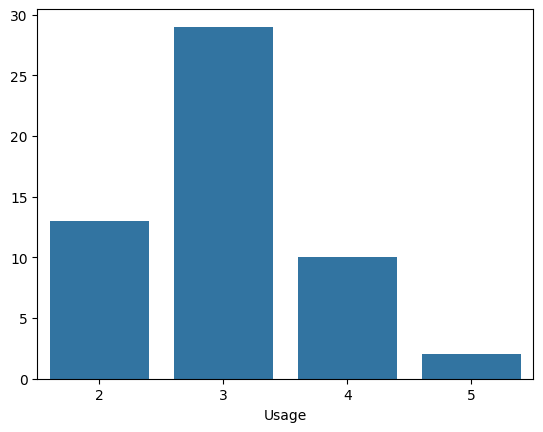

In [154]:
usage_counts = second_product_final['Usage'].value_counts().sort_index()
usage_counts

sns.barplot(x = usage_counts.index,y=usage_counts.values)
plt.show()

In [ ]:
# It is famous amonst the people who wants to use it 3 times in a week

<Axes: ylabel='count'>

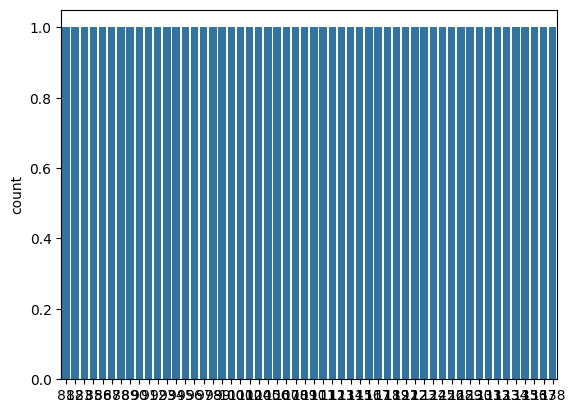

In [155]:
# Fitness: How do customers rate their own fitness level? What is the average self-rated fitness level?

sns.countplot(second_product_final['Fitness'])

# Repeatig the similar activity to convert continous to discrete

<Axes: xlabel='Fitness'>

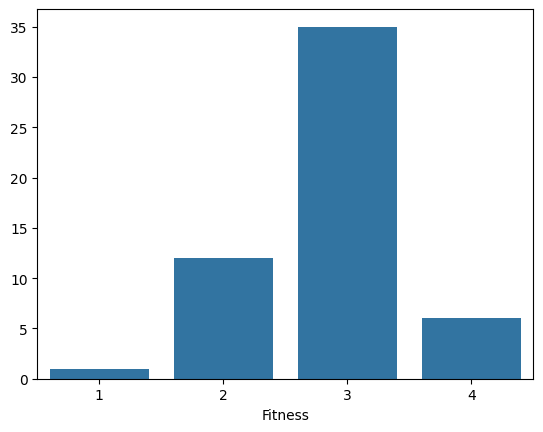

In [156]:
fitness_counts = second_product_final['Fitness'].value_counts().sort_index()


sns.barplot(x = fitness_counts.index,y=fitness_counts.values)

In [ ]:
# Customer who are rating themselves 3 are taking this product

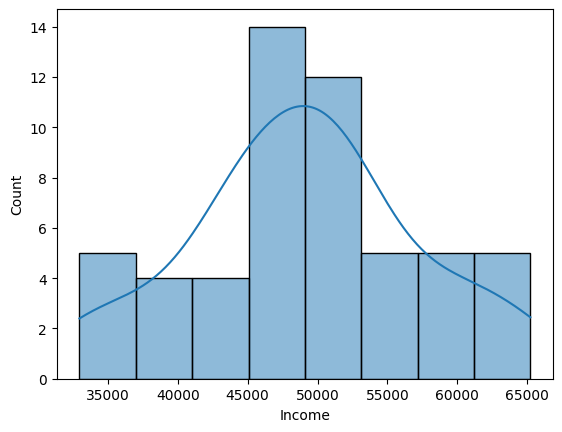

In [157]:
# Income: What is the income distribution of customers? What is the average income?

sns.histplot(second_product_final['Income'],kde=True)
plt.show()

In [ ]:
# Customers whose income is between $ 45000 - $55000 prefers the product

# Summarizing the findings till now (Customer Profile for KP481):

Based on the univariate analysis for the KP481 product, the typical customer is between 18 and 35 years old, making up about 78% of buyers, with a higher preference among female customers. They are more likely to be partnered and primarily plan to use the treadmill 3 times per week. These customers typically rate their fitness level as 3 and have incomes ranging from $45,000 to $55,000.

## KP481 Product

In [158]:
third_product = df[df['Product'] == 'KP781']
third_product.shape # All the data belong to KP281 are filtered

(40, 9)

In [159]:
third_product.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
140,KP781,22,Male,14,Single,4,3,48658,106
141,KP781,22,Male,16,Single,3,5,54781,120
142,KP781,22,Male,18,Single,4,5,48556,200
143,KP781,23,Male,16,Single,4,5,58516,140
144,KP781,23,Female,18,Single,5,4,53536,100


In [160]:
third_product.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000
mean,29.100000,17.325000,4.775000,4.625000,75441.57500,166.900000
std,6.971738,1.639066,0.946993,0.667467,18505.83672,60.066544
min,22.000000,14.000000,3.000000,3.000000,48556.00000,80.000000
25%,24.750000,16.000000,4.000000,4.000000,58204.75000,120.000000
50%,27.000000,18.000000,5.000000,5.000000,76568.50000,160.000000
75%,30.250000,18.000000,5.000000,5.000000,90886.00000,200.000000
max,48.000000,21.000000,7.000000,5.000000,104581.00000,360.000000


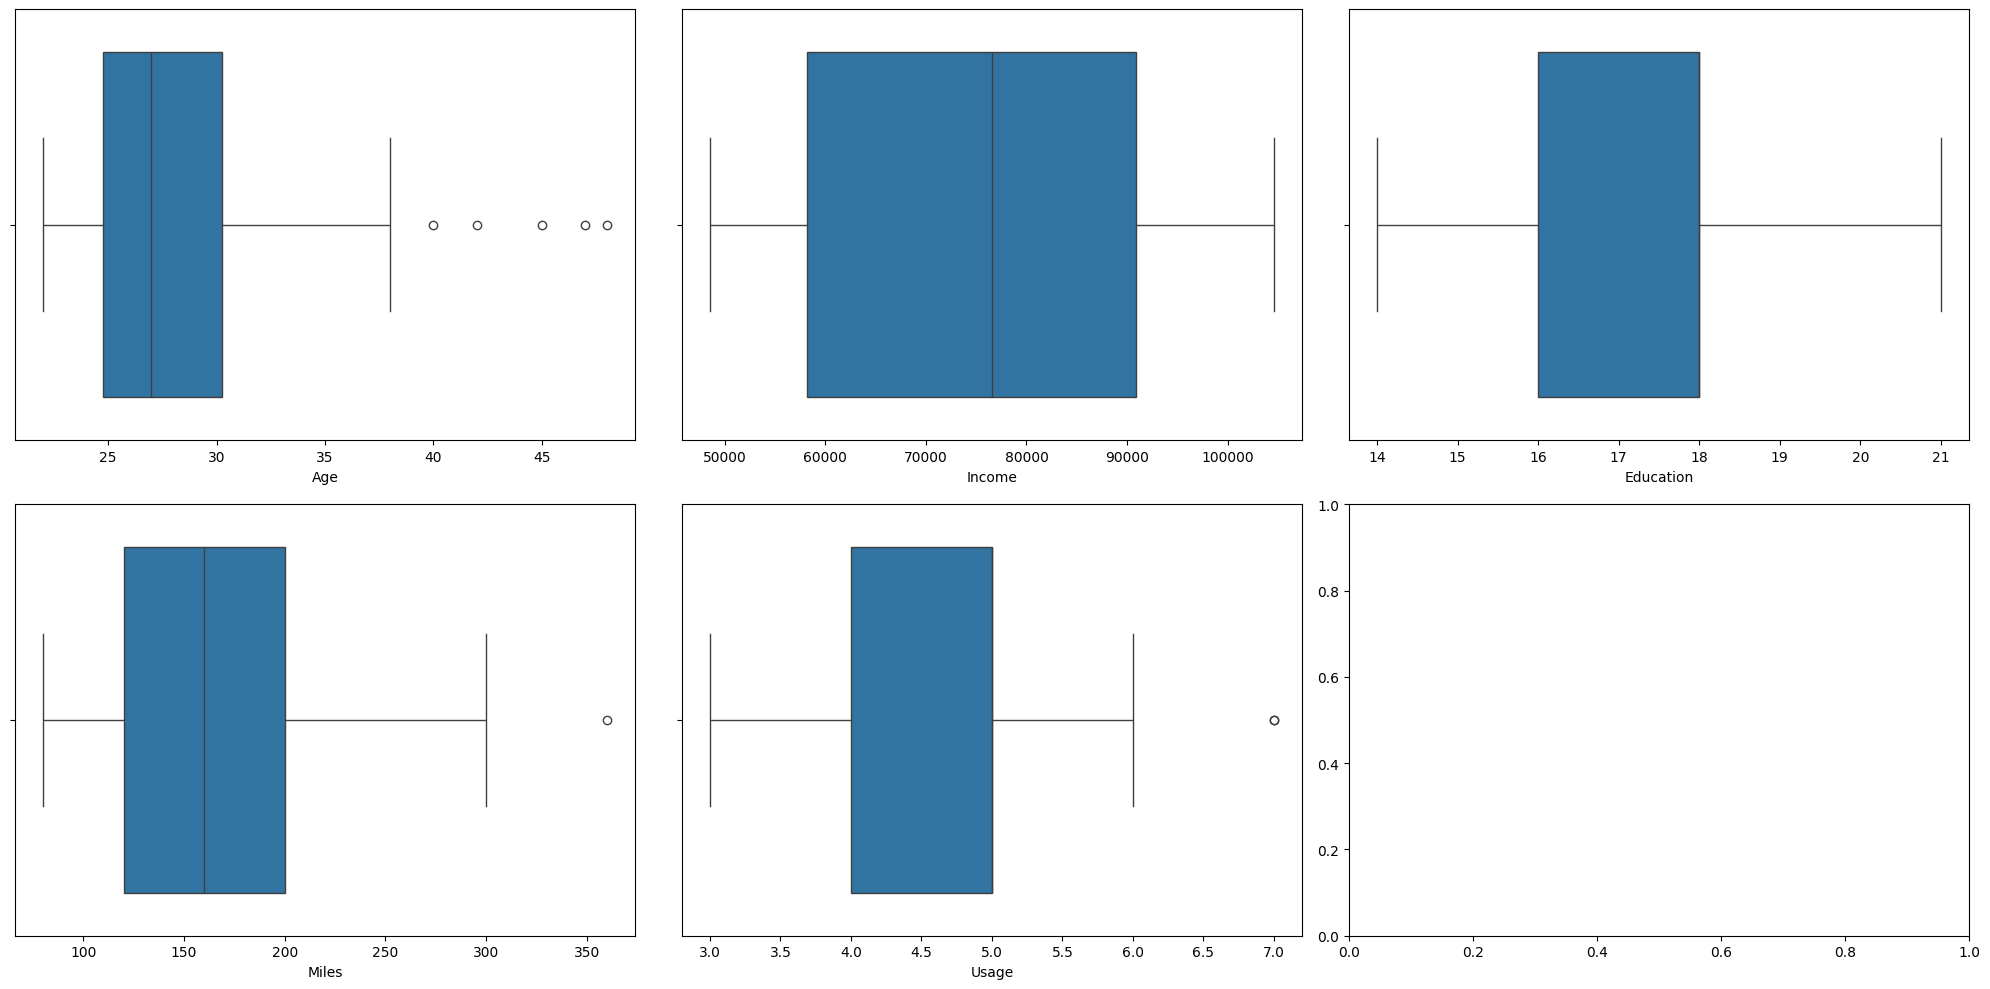

In [161]:
# First check for outliers for all columns

fig, ax = plt.subplots(2, 3, figsize=(20, 10))

sns.boxplot(x=third_product['Age'], ax=ax[0, 0])
sns.boxplot(x=third_product['Income'], ax=ax[0, 1])
sns.boxplot(x=third_product['Education'], ax=ax[0, 2])
sns.boxplot(x=third_product['Miles'], ax=ax[1, 0])
sns.boxplot(x=third_product['Usage'], ax=ax[1, 1])


plt.tight_layout()
plt.show()

In [ ]:
# There are some outliers so let's treat them

In [162]:
# Outliers treatment for Age

q1 = third_product['Age'].quantile(0.25)
q3 = third_product['Age'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

third_product_mod1 = third_product[(third_product['Age'] >= lower_bound) & (third_product['Age'] <= upper_bound)]

In [165]:
# Outliers treatment for Miles

q1 = third_product_mod1['Miles'].quantile(0.25)
q3 = third_product_mod1['Miles'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

third_product_mod2 = third_product_mod1[(third_product_mod1['Miles'] >= lower_bound) & (third_product_mod1['Miles'] <= upper_bound)]


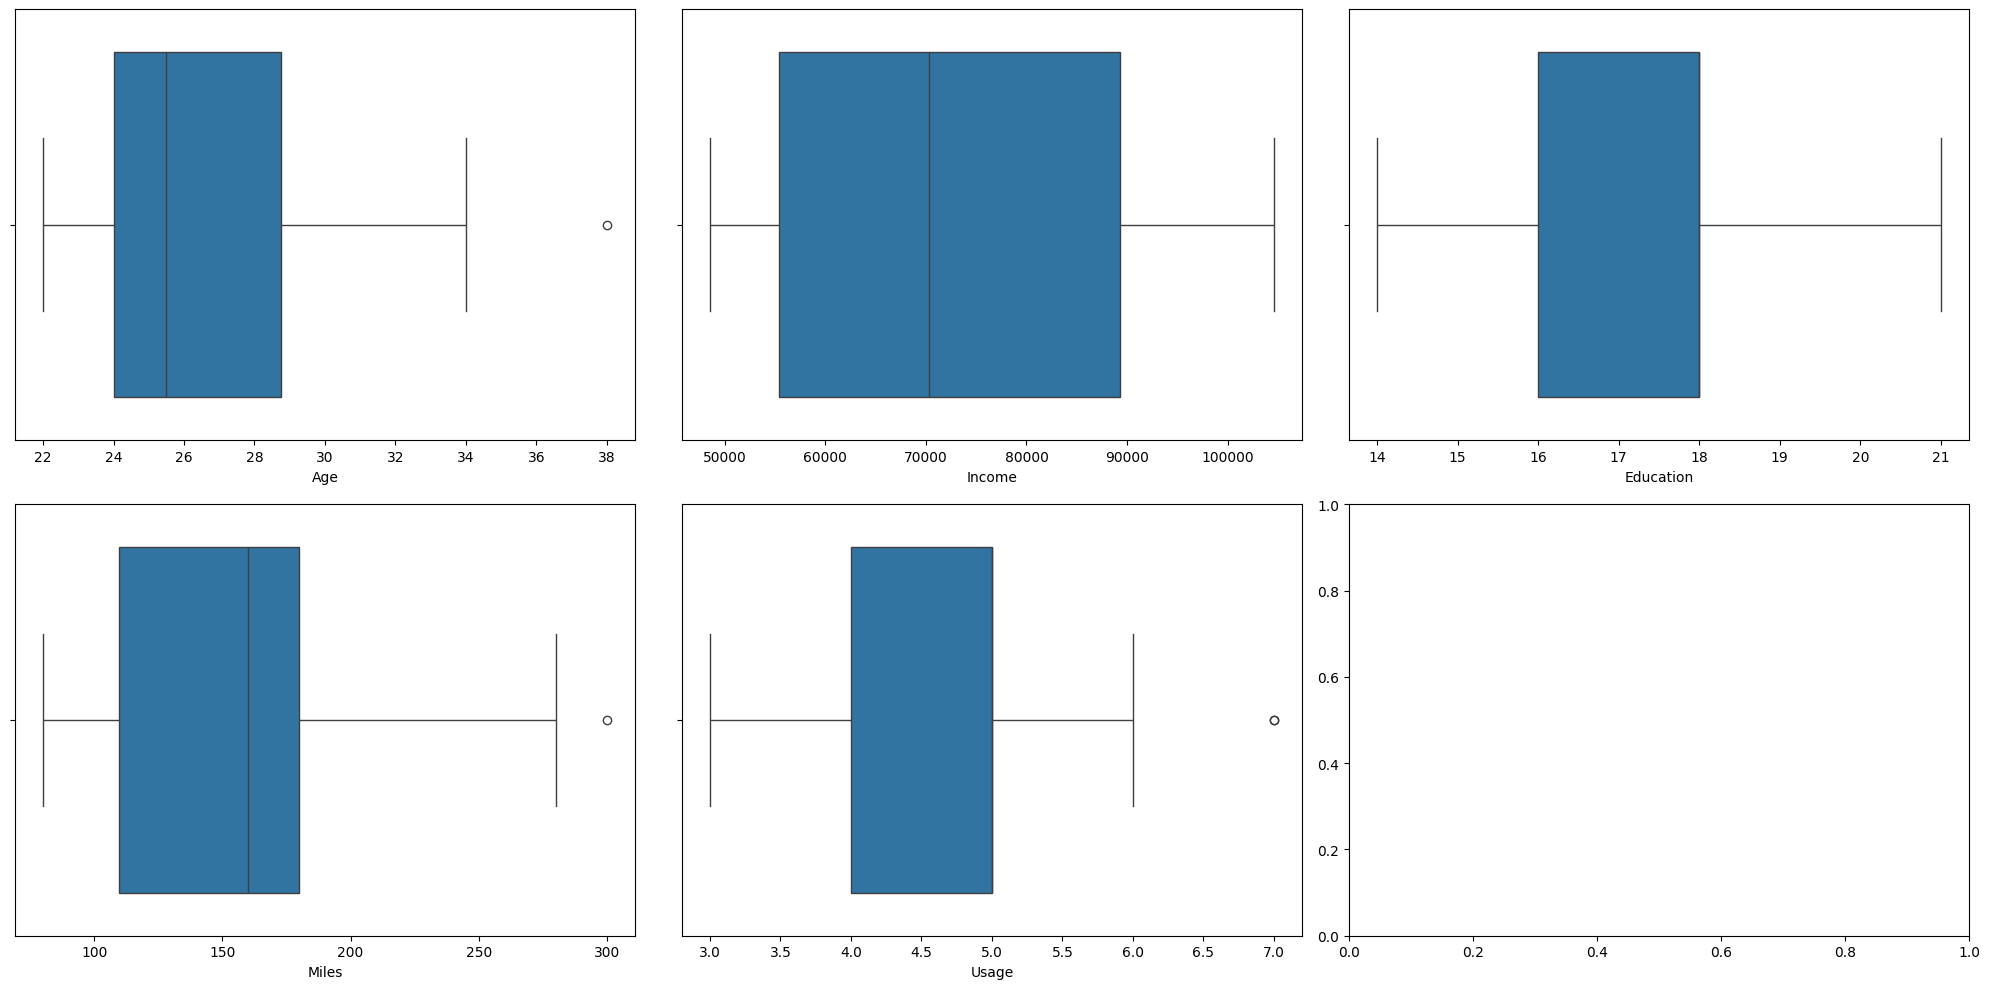

In [166]:
# Redrawing the box plot

fig, ax = plt.subplots(2, 3, figsize=(20, 10))

sns.boxplot(x=third_product_mod2['Age'], ax=ax[0, 0])
sns.boxplot(x=third_product_mod2['Income'], ax=ax[0, 1])
sns.boxplot(x=third_product_mod2['Education'], ax=ax[0, 2])
sns.boxplot(x=third_product_mod2['Miles'], ax=ax[1, 0])
sns.boxplot(x=third_product_mod2['Usage'], ax=ax[1, 1])


plt.tight_layout()
plt.show()

In [170]:
# Still there is an outlier for Age, lets treat it:

q1 = third_product_mod2['Age'].quantile(0.25)
q3 = third_product_mod2['Age'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

third_product_mod3 = third_product_mod2[(third_product_mod2['Age'] >= lower_bound) & (third_product_mod2['Age'] <= upper_bound)]

In [171]:
# Still there is an outlier for Miles, lets treat it:

q1 = third_product_mod3['Miles'].quantile(0.25)
q3 = third_product_mod3['Miles'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

third_product_final = third_product_mod3[(third_product_mod3['Miles'] >= lower_bound) & (third_product_mod3['Miles'] <= upper_bound)]

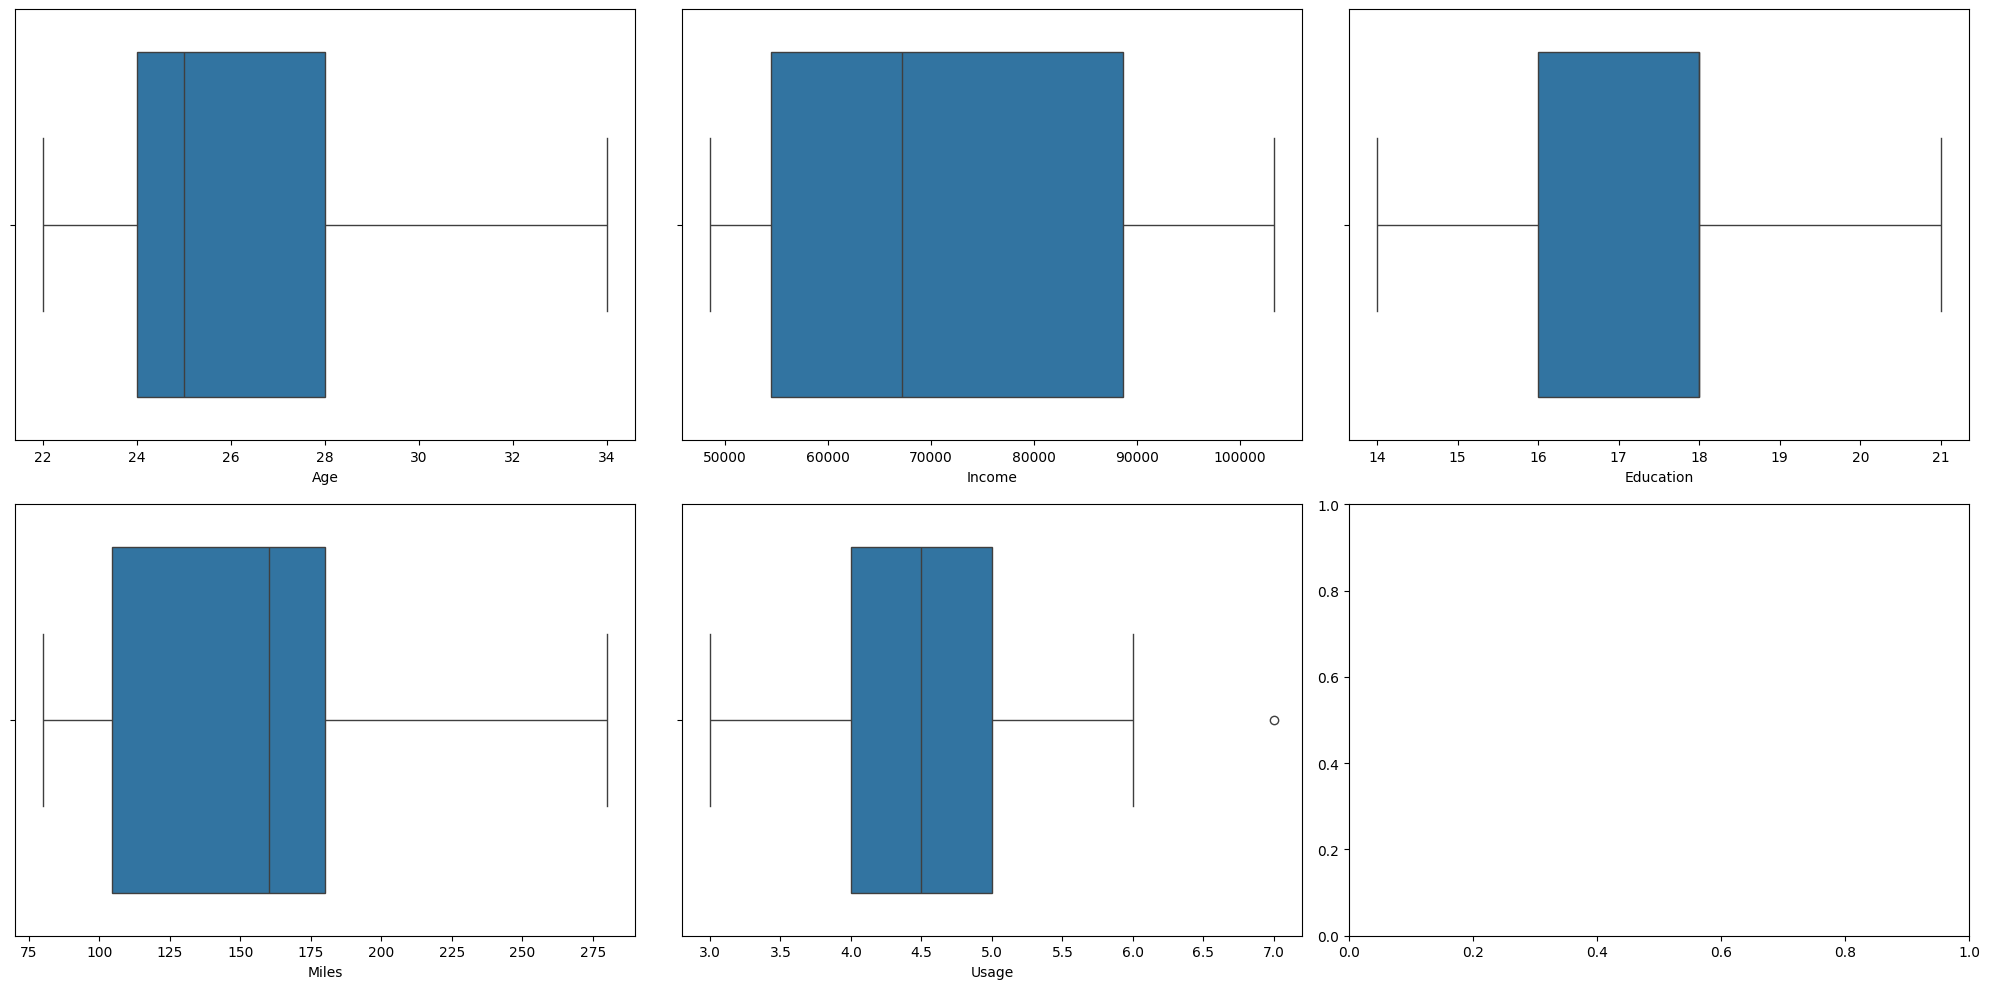

In [172]:
# Redrawing the box plot

fig, ax = plt.subplots(2, 3, figsize=(20, 10))

sns.boxplot(x=third_product_final['Age'], ax=ax[0, 0])
sns.boxplot(x=third_product_final['Income'], ax=ax[0, 1])
sns.boxplot(x=third_product_final['Education'], ax=ax[0, 2])
sns.boxplot(x=third_product_final['Miles'], ax=ax[1, 0])
sns.boxplot(x=third_product_final['Usage'], ax=ax[1, 1])


plt.tight_layout()
plt.show()

In [173]:
third_product_final.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,32.00000,32.000000,32.00000,32.000000,32.000000,32.000000
mean,26.25000,17.312500,4.71875,4.562500,70969.156250,156.437500
std,3.14181,1.554131,0.92403,0.715609,17710.424027,49.938632
min,22.00000,14.000000,3.00000,3.000000,48556.000000,80.000000
25%,24.00000,16.000000,4.00000,4.000000,54469.750000,104.500000
50%,25.00000,18.000000,4.50000,5.000000,67231.000000,160.000000
75%,28.00000,18.000000,5.00000,5.000000,88707.250000,180.000000
max,34.00000,21.000000,7.00000,5.000000,103336.000000,280.000000


# Comments

### Post Outliers are treated, lets dig into uni-variate analysis
*   Age: What is the typical age range of customers? Are there any age groups that buy more than others?
*   Gender: What is the gender distribution of customers?
*   Education: What are the common education levels of customers?
*   MaritalStatus: What is the marital status distribution of customers? Are they mostly single or partnered?
*   Usage: How often do customers plan to use the treadmill per week? What is the most common planned usage?
*   Fitness: How do customers rate their own fitness level? What is the average self-rated fitness level?
*   Income: What is the income distribution of customers? What is the average income?

In [174]:
third_product_final.head(5)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
140,KP781,22,Male,14,Single,4,3,48658,106
141,KP781,22,Male,16,Single,3,5,54781,120
142,KP781,22,Male,18,Single,4,5,48556,200
143,KP781,23,Male,16,Single,4,5,58516,140
144,KP781,23,Female,18,Single,5,4,53536,100


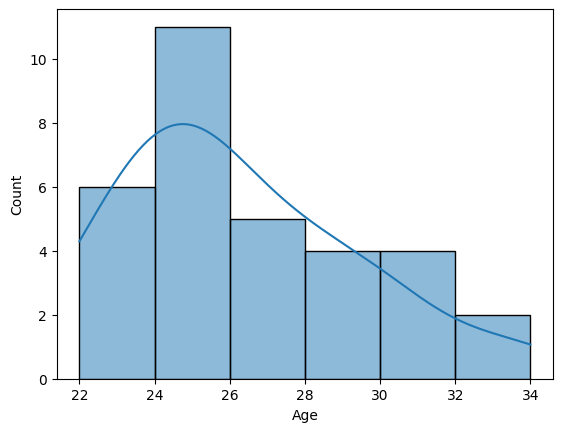

In [176]:
# Age: What is the typical age range of customers? Are there any age groups that buy more than others?

sns.histplot(third_product_final['Age'],kde=True)
plt.show()

In [ ]:
# It is clear from above graph that customers from age groups between 24-26 consititues major portion

<Axes: xlabel='count', ylabel='Gender'>

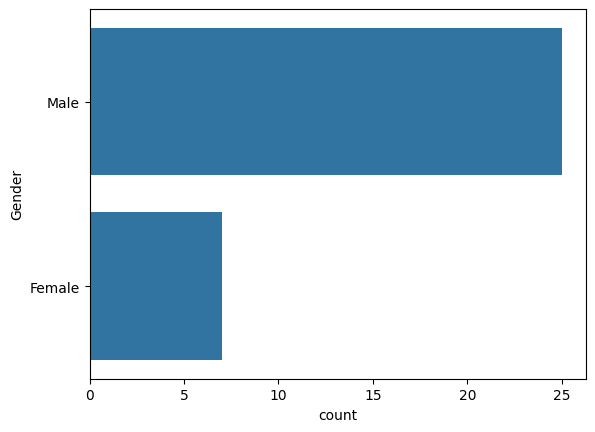

In [178]:
# Gender: What is the gender distribution of customers?

sns.countplot(third_product_final['Gender'])

In [ ]:
# Male customers prefer this product more than their counterpart

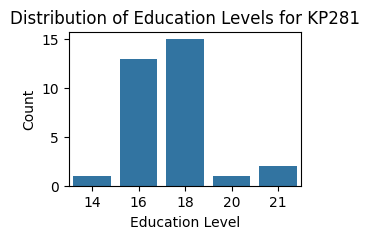

In [179]:
# Education: What are the common education levels of customers?

education_counts = third_product_final['Education'].value_counts().sort_index()  # Taking discrete values of the Education and then plotting it

plt.figure(figsize=(3, 2))
sns.barplot(x=education_counts.index, y=education_counts.values)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Distribution of Education Levels for KP281')
plt.show()

In [ ]:
# the above graphs shows that education grup 18 and 16 are most preferred ones

<Axes: xlabel='count', ylabel='MaritalStatus'>

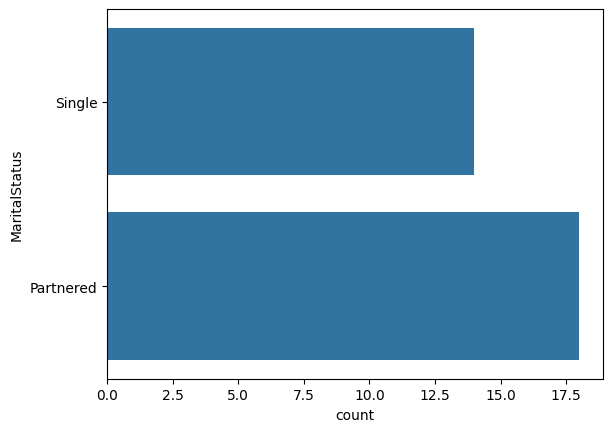

In [180]:
# MaritalStatus: What is the marital status distribution of customers? Are they mostly single or partnered?

sns.countplot(third_product_final['MaritalStatus'])

In [ ]:
# Partenred i.e. Maried couples are frequent buyer of this product

<Axes: ylabel='count'>

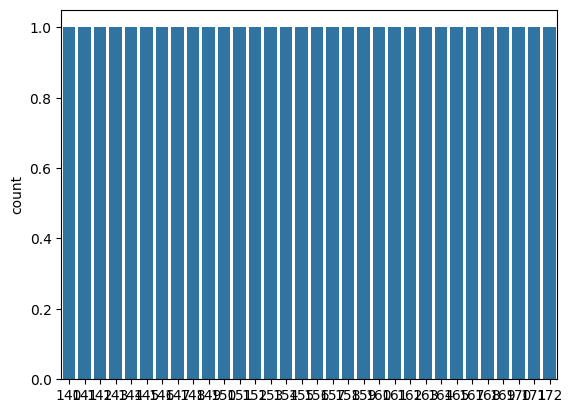

In [181]:
# Usage: How often do customers plan to use the treadmill per week? What is the most common planned usage?

sns.countplot(third_product_final['Usage'])

# Countplot might be interpreting the numerical data as continous instead of discrete.
# This is causing it to group all values together. Lets calculate the data and use it
# to plot the graph

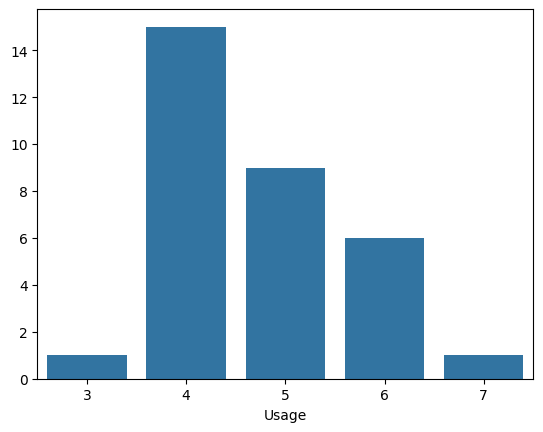

In [182]:
usage_counts = third_product_final['Usage'].value_counts().sort_index()
usage_counts

sns.barplot(x = usage_counts.index,y=usage_counts.values)
plt.show()

In [ ]:
# It is famous amonst the people who wants to use it 4 times in a week

<Axes: ylabel='count'>

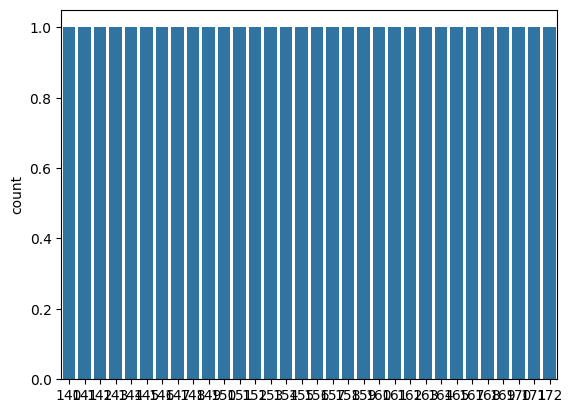

In [183]:
# Fitness: How do customers rate their own fitness level? What is the average self-rated fitness level?

sns.countplot(third_product_final['Fitness'])

# Repeatig the similar activity to convert continous to discrete

<Axes: xlabel='Fitness'>

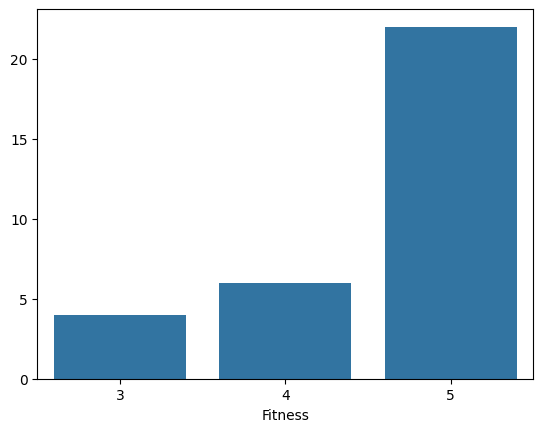

In [184]:
fitness_counts = third_product_final['Fitness'].value_counts().sort_index()


sns.barplot(x = fitness_counts.index,y=fitness_counts.values)

In [ ]:
# Customer who are rating themselves 5 are taking this product

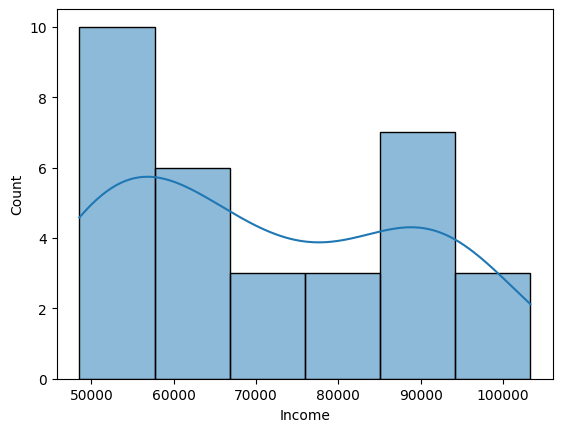

In [185]:
# Income: What is the income distribution of customers? What is the average income?

sns.histplot(third_product_final['Income'],kde=True)
plt.show()

In [ ]:
# Customers whose income is between $ 50000 - $60000 prefers the product and generally this is preferred by high values customer

# Summarizing the findings till now (Customer Profile for KP781):

Based on the univariate analysis for the KP781 product, the typical customer is between 24 and 26 years old, with a higher preference among male customers. They commonly have education levels of 18 and 16 years and are more likely to be partnered. These customers primarily plan to use the treadmill 4 times per week and rate their fitness level as 5. Their income typically falls between $50,000 and $60,000, and this product is generally preferred by high-value customers.

# Collating the information obtained till now wrt three product:

### * KP-281: Based on the univariate analysis for the KP281 product, the typical customer is between 18 and 30 years old, making up about 65% of buyers, with a nearly equal distribution between genders. They commonly have education levels of 14 or 16 years and are more likely to be partnered. These customers primarily plan to use the treadmill 3 times per week and rate their fitness level as 3. Their income typically falls between  45,000𝑎𝑛𝑑 55,000.

### * KP-481: Based on the univariate analysis for the KP481 product, the typical customer is between 18 and 35 years old, making up about 78% of buyers, with a higher preference among female customers. They are more likely to be partnered and primarily plan to use the treadmill 3 times per week. These customers typically rate their fitness level as 3 and have incomes ranging from  45,000𝑡𝑜 55,000.

### * KP-781: Based on the univariate analysis for the KP781 product, the typical customer is between 24 and 26 years old, with a higher preference among male customers. They commonly have education levels of 18 and 16 years and are more likely to be partnered. These customers primarily plan to use the treadmill 4 times per week and rate their fitness level as 5. Their income typically falls between  50,000𝑎𝑛𝑑 60,000, and this product is generally preferred by high-value customers.

# Bi-variate Analysis

In [193]:
first_product.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


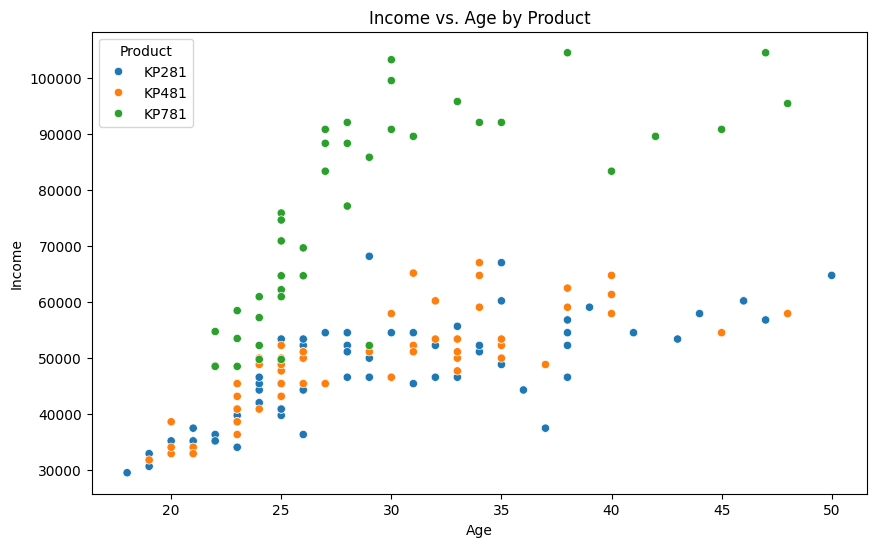

In [199]:
# Create a scatter plot of Income vs. Age, colored by Product
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Income', hue='Product')
plt.title('Income vs. Age by Product')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

Inferences:

* The KP281 and KP481 treadmills are more popular among younger to middle-aged individuals with lower to moderate incomes. There isn't a strong differentiation between KP281 and KP481 based on just Age and Income in this plot, suggesting other factors might influence the choice between these two models.
* The KP781 treadmill is clearly targeted towards a different customer segment: older individuals with higher incomes. This suggests it's a premium product purchased by customers with more disposable income.

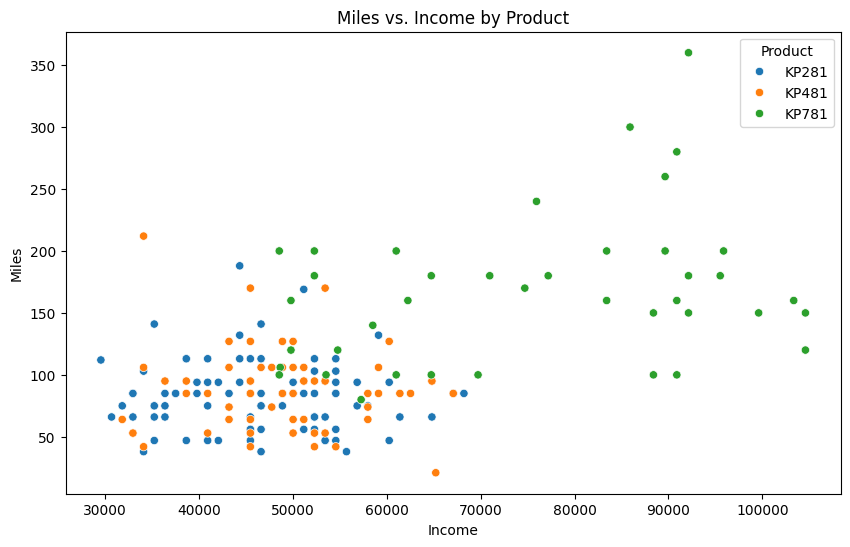

In [200]:
# Create a scatter plot of Miles vs. Income, colored by Product
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='Miles', hue='Product')
plt.title('Miles vs. Income by Product')
plt.xlabel('Income')
plt.ylabel('Miles')
plt.show()

Inferences

* While for the lower-end products (KP281 and KP481), there isn't a very strong relationship between income and miles, the plot clearly shows that customers who purchase the high-end product (KP781) have both higher incomes and higher expected mileage.
* Customers willing to invest in a more expensive treadmill (indicated by higher income) also tend to be those who plan to use it more intensively (indicated by higher miles).
* This reinforces the idea that the KP781 is for more serious users who are likely to be more dedicated to their fitness goals and have the income to support that investment.

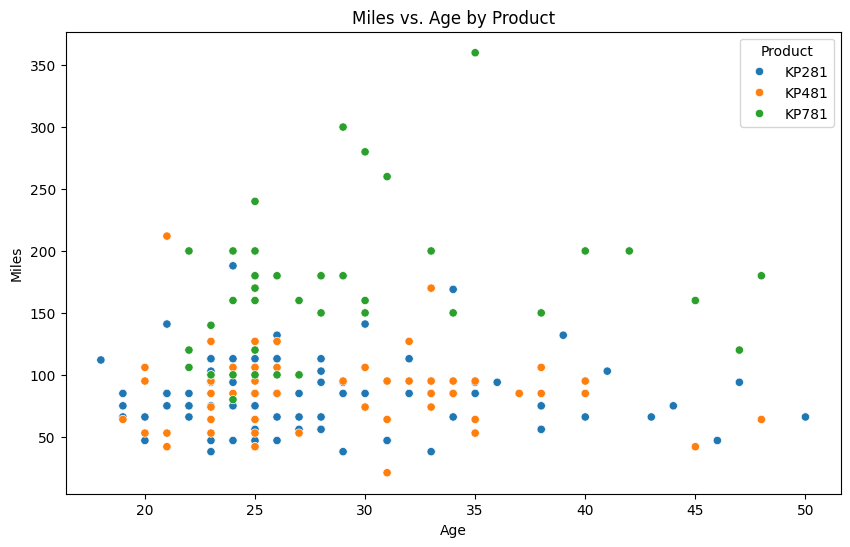

In [201]:
# Create a scatter plot of Miles vs. Age, colored by Product
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Miles', hue='Product')
plt.title('Miles vs. Age by Product')
plt.xlabel('Age')
plt.ylabel('Miles')
plt.show()

Inferences:

* This plot suggests that for the KP281 and KP481, age doesn't seem to be a strong predictor of expected mileage. Customers of various ages who buy these models generally plan for lower weekly mileage.

* This plot, combined with the Income vs. Age plot, helps build a clearer picture of the distinct customer profile for the KP781 as higher-income individuals who are serious about running, regardless of being younger or middle-aged.

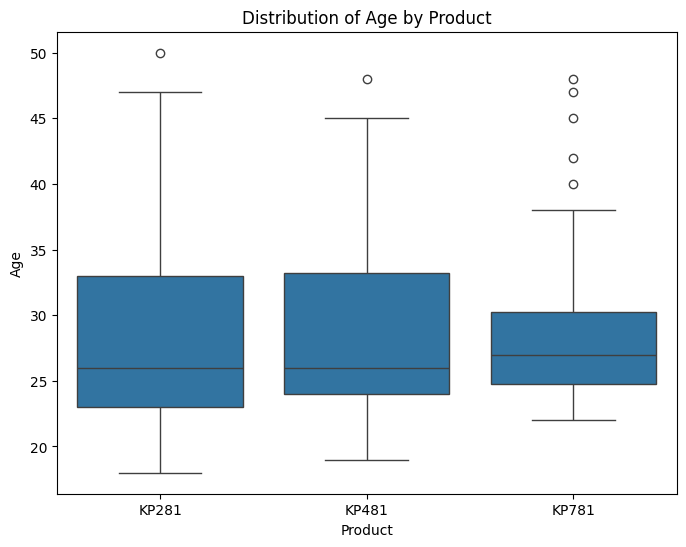

In [202]:
# Create box plots of Age by Product
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Product', y='Age')
plt.title('Distribution of Age by Product')
plt.xlabel('Product')
plt.ylabel('Age')
plt.show()

Inferences:

* Both the KP281 and KP481 attract a similar age demographic, primarily younger to middle-aged adults. The KP781 also attracts customers from this general age range, but with a slightly higher median age and a tighter concentration, suggesting it appeals more to established professionals within that age bracket.

In [210]:
# Constructing a two-way contingency table between 'Product' and 'Gender'
ct_gender = pd.crosstab(df['Product'], df['Gender'], margins=True)
print(ct_gender)

Gender   Female  Male  All
Product                   
KP281        40    40   80
KP481        29    31   60
KP781         7    33   40
All          76   104  180


In [221]:
# Constructing a two-way contingency table between 'Product' and 'MaritalStatus'
ct_marital_status = pd.crosstab(df['Product'], df['MaritalStatus'], margins=True)
print(ct_marital_status)

MaritalStatus  Partnered  Single  All
Product                              
KP281                 48      32   80
KP481                 36      24   60
KP781                 23      17   40
All                  107      73  180


In [222]:
# Probability that partnered customer buy product is:

ct_marital_status.loc['All','Partnered'] / ct_marital_status.loc['All','All']

np.float64(0.5944444444444444)

In [223]:
# Probability that single customer buy product is:

ct_marital_status.loc['All','Single'] / ct_marital_status.loc['All','All']

np.float64(0.40555555555555556)

In [224]:
# Probability that customer will buy KP281 given that they are partnered is:

ct_marital_status.loc['KP281','Partnered'] / ct_marital_status.loc['KP281','All']


np.float64(0.6)

In [225]:
# Probability that customer will buy KP281 given that they are single is:

ct_marital_status.loc['KP281','Single'] / ct_marital_status.loc['KP281','All']


np.float64(0.4)

In [226]:
# Probability that male customer will buy product is:


ct_gender.loc['All','Male'] / ct_gender.loc['All','All']

np.float64(0.5777777777777777)

In [227]:
# Probability that male customer will buy KP281 product is:

ct_gender.loc['KP281','Male'] / ct_gender.loc['KP281','All']


np.float64(0.5)

# Business Recommendations

Based on the analysis of the AeroFit treadmill customer data, here are some recommendations:

**For the KP281 Product:**

*   **Marketing Focus:** Target marketing campaigns towards younger to middle-aged adults (18-30 years old) with lower to moderate incomes (around $45,000 - $55,000). Highlight the product's value and suitability for general fitness and moderate weekly usage (around 3 times per week).
*   **Sales Strategy:** Emphasize the product's benefits for partnered individuals, as they are more likely to purchase this model. Sales pitches can focus on shared fitness goals for couples or families.
*   **Educational Content:** Since education levels of 14 and 16 years are common, provide clear and easy-to-understand product information and guides.

**For the KP481 Product:**

*   **Marketing Focus:** Similar to KP281, target younger to middle-aged adults (18-35 years old) with lower to moderate incomes ($45,000 - $55,000). However, tailor messaging to appeal more to female customers, as they show a higher preference for this model.
*   **Sales Strategy:** Continue to emphasize the benefits for partnered individuals.
*   **Product Positioning:** Since the customer profile is very similar to KP281 in terms of age, income, and usage frequency, consider how to clearly differentiate the KP481 in marketing to avoid cannibalization and highlight its specific advantages, perhaps focusing on design or slightly different features if applicable.

**For the KP781 Product:**

*   **Marketing Focus:** Target higher-income individuals (around $50,000 - $60,000 and above) who are serious about running and fitness. Highlight the product's advanced features, durability, and suitability for higher weekly mileage (around 4+ times per week and higher expected miles).
*   **Sales Strategy:** Focus on the value proposition for customers who rate their fitness level as 5 and are looking for a high-performance machine. Emphasize the long-term benefits and capabilities of the product for dedicated runners.
*   **Channel Strategy:** Consider marketing and sales channels that reach a more affluent and fitness-focused demographic.

**General Recommendations:**

*   **Marital Status:** Given that partnered individuals are more frequent buyers across all products, explore targeted promotions or product bundles that appeal to couples or families.
*   **Fitness Level and Usage:** Tailor marketing messages and product demonstrations to different fitness levels and planned usage frequencies. For example, highlight the ease of use for beginners (Fitness level 3 for KP281/KP481) and the advanced training programs for more serious users (Fitness level 5 for KP781).
*   **Further Analysis:** Conduct further analysis to understand the factors that differentiate KP281 and KP481 buyers more clearly, as their profiles are quite similar based on the current analysis. Explore other variables or potential interactions.